### Replacing Fourier Bank using a FNO-type layer

For Elliptical domain equation.

In [1]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 111.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt
from time import time
import os

f_set = [ 300, 600, 750, 900,  ]
c = 343.0
k_set = [ ( 2.0 * np.pi * f ) / c for f in f_set ]

Nf = 6400
adam_epochs = 2000

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( "Active Hardware Target:", device )

class Standard_MLP_PINN ( nn.Module ):
    def __init__ ( self, hidden_dim = 128, n_hidden_layers = 7 ):
        super().__init__()
        
        layers = []
        layers.append ( nn.Linear ( 2, hidden_dim ) )
        
        for _ in range ( n_hidden_layers ):
            layers.append ( nn.Linear ( hidden_dim, hidden_dim ) )
            
        self.mlp = nn.ModuleList ( layers )
        
        self.output_layer = nn.Linear ( hidden_dim, 1 )
        
        self.apply ( self.init_weights )

    def init_weights ( self, m ):
        if isinstance ( m, nn.Linear ):
            torch.nn.init.xavier_uniform_ ( m.weight )
            if m.bias is not None:
                m.bias.data.fill_ ( 0.0 )

    def forward ( self, xy ):
        x_coord = xy[:, 0:1]
        y_coord = xy[:, 1:2]
        
        z = xy
        for layer in self.mlp:
            z = torch.sin ( layer ( z ) )
            
        network_out = self.output_layer ( z )
        
        a = 1.0  
        b = 0.5  
        
        phi_e = ( 1.0 - ( ( x_coord / a )**2 + ( y_coord / b )**2 ) ) / 2.0
        W = 1.0 - phi_e
        psi_R = 1.0  
        
        psi_t = W * psi_R + phi_e * network_out
        
        return psi_t
        
def net_loss ( model, xy, k, return_pointwise = False ):
    p = model ( xy )
    
    dp_dxy = torch.autograd.grad (
        p, xy, grad_outputs = torch.ones_like ( p ),
        create_graph = True, retain_graph = True
    )[0]
    dp_dx = dp_dxy[:, 0:1]
    dp_dy = dp_dxy[:, 1:2]
    
    d2p_dx2 = torch.autograd.grad (
        dp_dx, xy, grad_outputs = torch.ones_like ( dp_dx ),
        create_graph = True, retain_graph = True
    )[0][:, 0:1]
    
    d2p_dy2 = torch.autograd.grad (
        dp_dy, xy, grad_outputs = torch.ones_like ( dp_dy ),
        create_graph = True, retain_graph = True
    )[0][:, 1:2]
    
    residual = ( d2p_dx2 + d2p_dy2 ) / ( k**2 ) + p

    if return_pointwise:
        return torch.abs ( residual )
    return torch.mean ( residual**2 )

xy_f_base = torch.rand ( Nf, 2, device = device ) * 1.96 - 0.98

models = []
loss_histories = []

model = Standard_MLP_PINN ( hidden_dim = 128, n_hidden_layers = 7 ).to ( device )
start = time()

for i, k in enumerate ( k_set ):
    
    xy_f = xy_f_base.clone()
    xy_f.requires_grad = True

    adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )

    loss_history = []

    print ( f"INFO: Adam Training Started For f = {f_set[i]} Hz" )    
    for epoch in range ( adam_epochs ):
        adam_opt.zero_grad()
        loss = net_loss ( model, xy_f, k )
        loss.backward()
        adam_opt.step()
        
        loss_history.append ( loss.item() )
        
        if ( epoch + 1 ) % 200 == 0:
            with torch.no_grad():
                xy_candidate = torch.rand ( 5000, 2, device = device ) * 1.96 - 0.98
            xy_candidate.requires_grad = True
            
            abs_residual = net_loss ( model, xy_candidate, k, return_pointwise = True )
            
            _, top_indices = torch.topk ( abs_residual.flatten(), 50 )
            xy_f = torch.cat ( [ xy_f.detach(), xy_candidate[top_indices].detach() ], dim = 0 )
            xy_f.requires_grad = True
            print ( f"INFO: f = {f_set[i]} Hz; Iteration: {len(loss_history)}; Loss: {loss.item():.6e}; Time: {time() - start:.2f}s" )

    print ( f"INFO: Adam Training Done For f = {f_set[i]} Hz\n" )

    define_iters = 5000

    opt = torch.optim.LBFGS (
        model.parameters(),
        lr = 1.0,
        max_iter = define_iters,
        line_search_fn = "strong_wolfe" )

    def closure():
        opt.zero_grad()
        loss = net_loss ( model, xy_f, k )
        loss.backward()
        
        loss_history.append ( loss.item() )
        if len ( loss_history ) % 1000 == 0:
            print ( f"INFO: Iteration: {len(loss_history)}; Loss: {loss.item():.6e}; Time: {time() - start:.2f}s" )
        return loss

    print ( f"INFO: LBFGS Training Started For f = {f_set[i]} Hz\n" )
    opt.step ( closure )
    print ( f"INFO: LBFGS Training Done For f = {f_set[i]} Hz\n" )
    
    models.append ( copy.deepcopy ( model ) )
    loss_histories.append ( loss_history )

Active Hardware Target: cuda
INFO: Adam Training Started For f = 300 Hz
INFO: f = 300 Hz; Iteration: 200; Loss: 6.130114e-01; Time: 8.92s
INFO: f = 300 Hz; Iteration: 400; Loss: 6.206095e-01; Time: 16.40s
INFO: f = 300 Hz; Iteration: 600; Loss: 6.281220e-01; Time: 23.92s
INFO: f = 300 Hz; Iteration: 800; Loss: 6.352449e-01; Time: 31.48s
INFO: f = 300 Hz; Iteration: 1000; Loss: 6.428858e-01; Time: 39.07s
INFO: f = 300 Hz; Iteration: 1200; Loss: 6.498040e-01; Time: 46.70s
INFO: f = 300 Hz; Iteration: 1400; Loss: 6.449732e-01; Time: 54.47s
INFO: f = 300 Hz; Iteration: 1600; Loss: 3.687615e-02; Time: 62.29s
INFO: f = 300 Hz; Iteration: 1800; Loss: 1.635149e-02; Time: 70.12s
INFO: f = 300 Hz; Iteration: 2000; Loss: 7.720661e-03; Time: 77.99s
INFO: Adam Training Done For f = 300 Hz

INFO: LBFGS Training Started For f = 300 Hz

INFO: LBFGS Training Done For f = 300 Hz

INFO: Adam Training Started For f = 600 Hz
INFO: f = 600 Hz; Iteration: 200; Loss: 6.466829e-02; Time: 115.27s
INFO: f = 600 

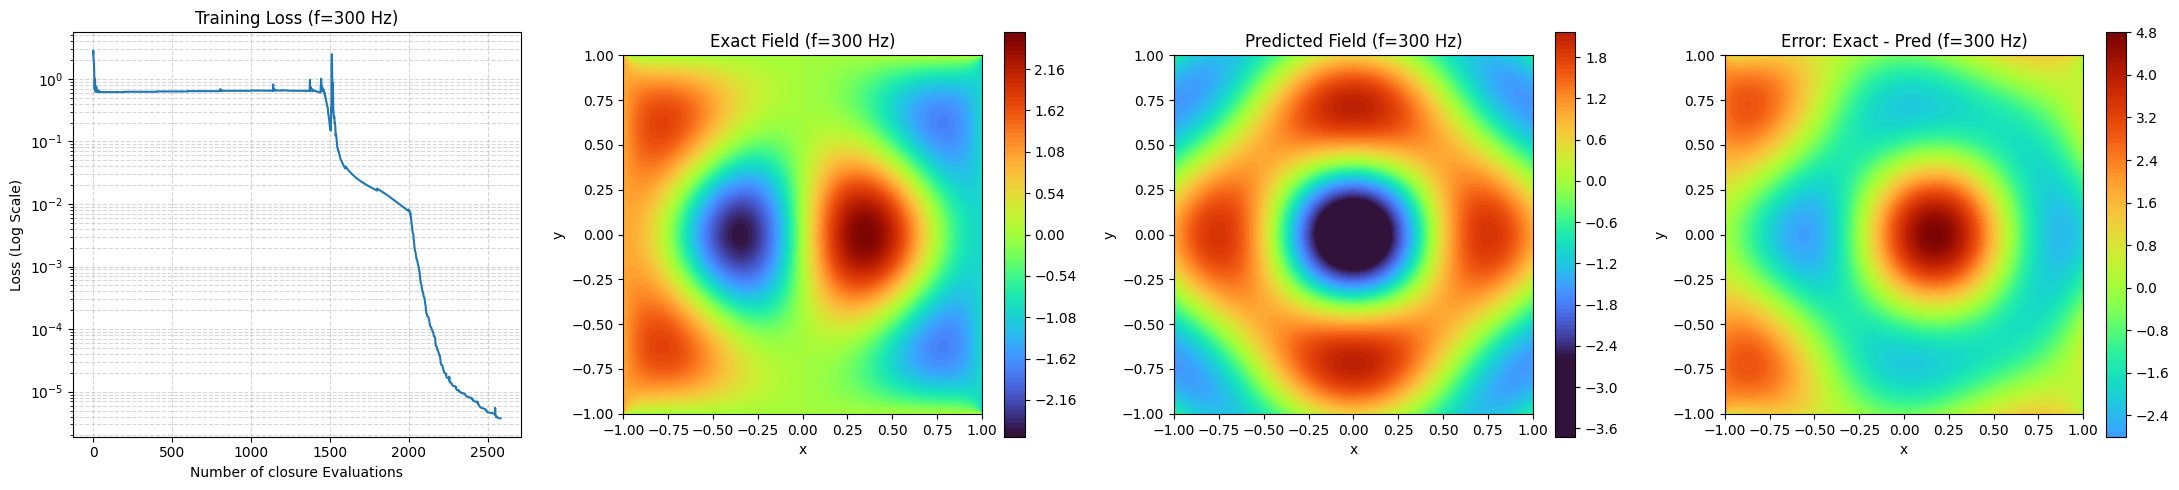

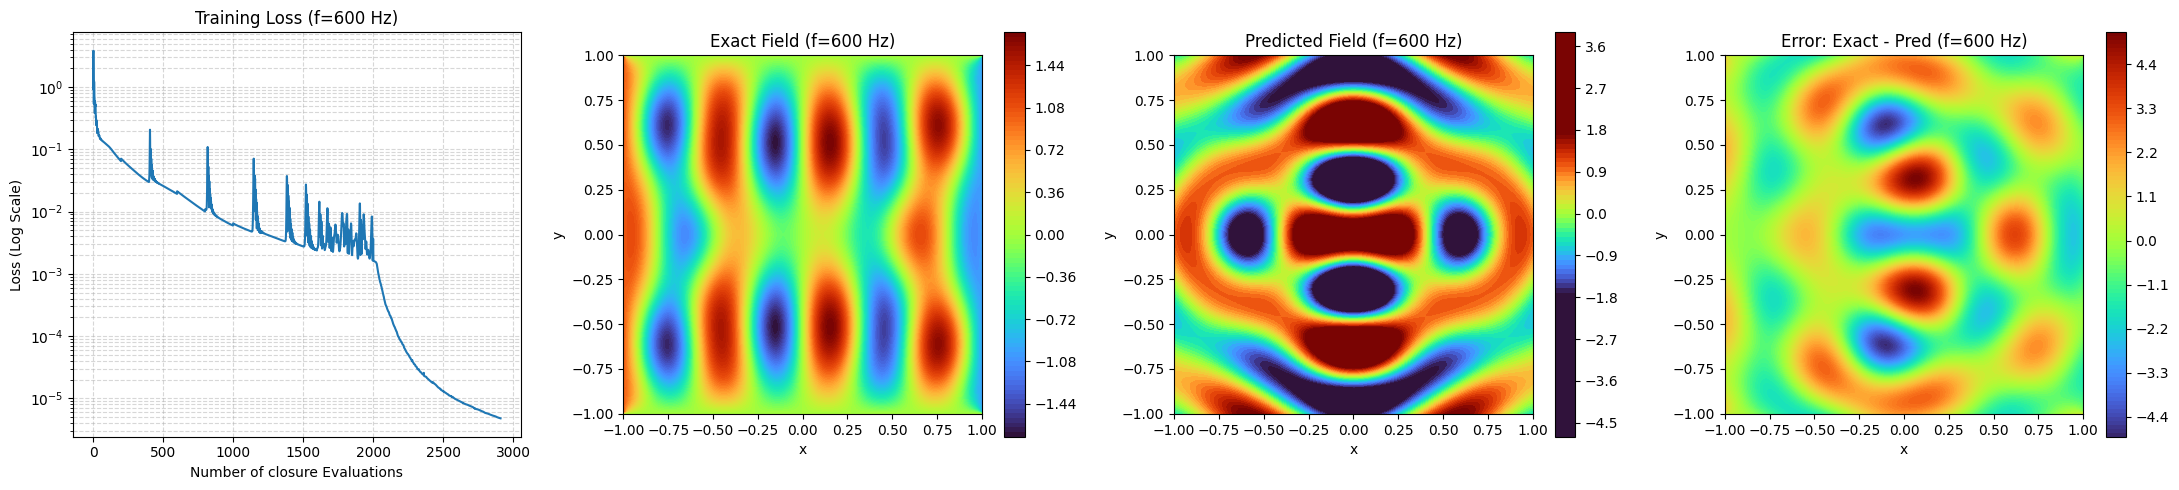

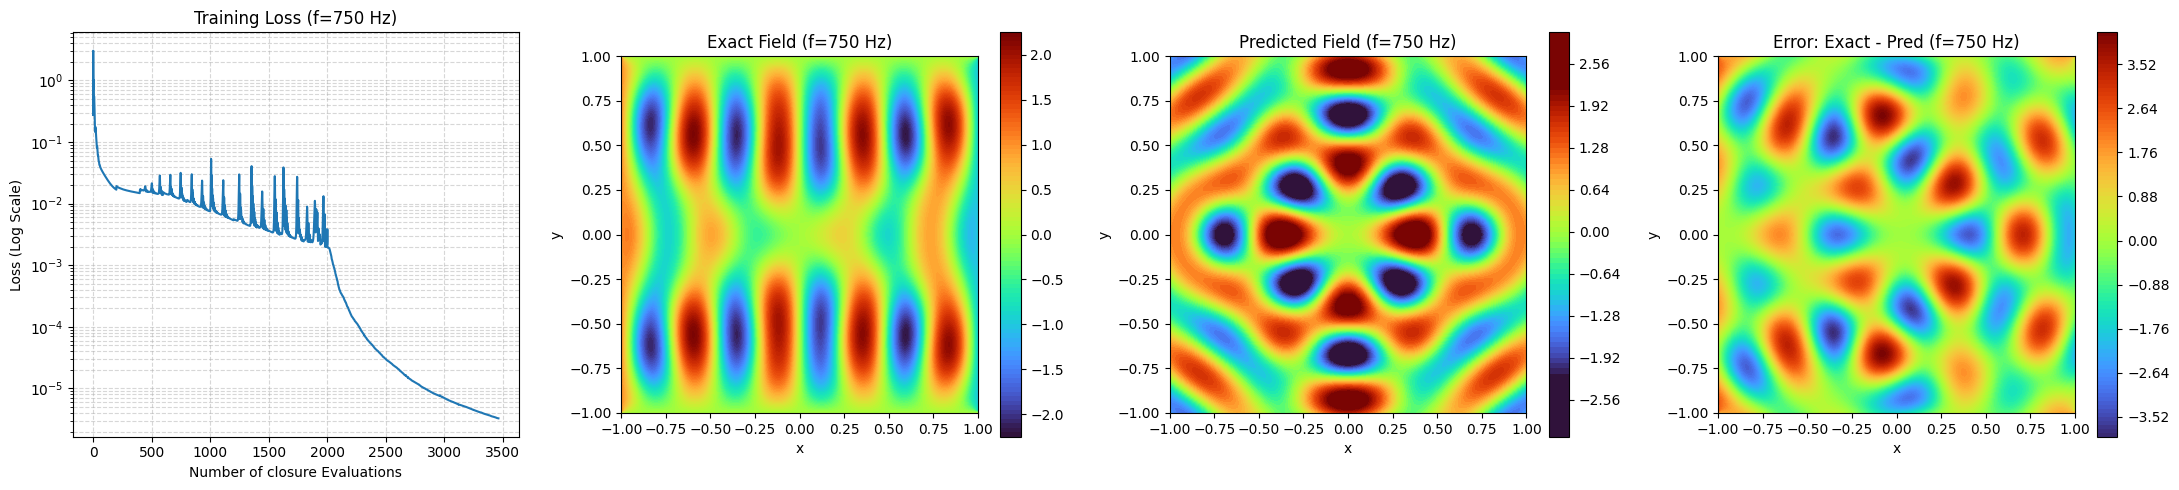

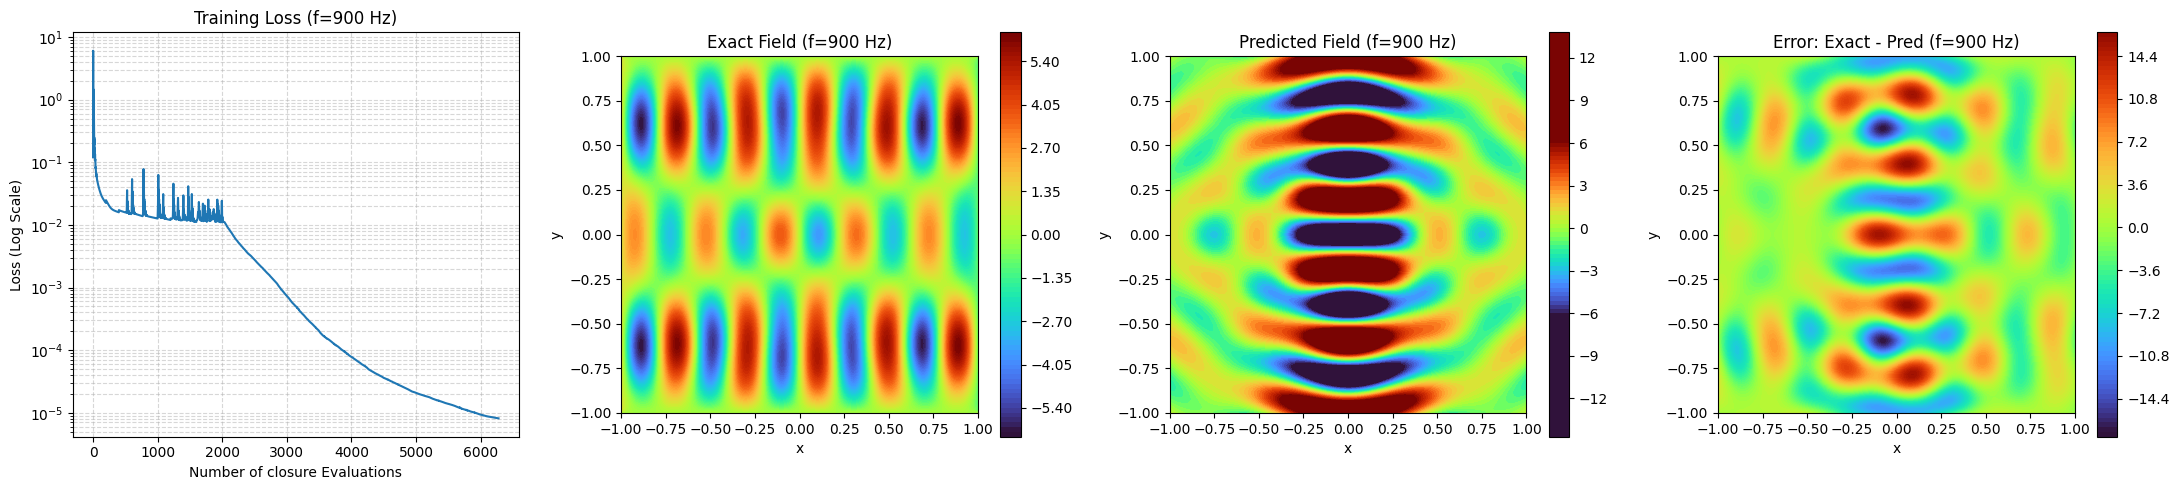

In [5]:
for idx, k in enumerate ( k_set ): 
    with torch.no_grad():
        x_plot = np.linspace ( -1, 1, 150 )
        y_plot = np.linspace ( -1, 1, 150 )
        X, Y = np.meshgrid ( x_plot, y_plot )
        xy_plot = torch.tensor ( np.column_stack ( ( X.flatten(), Y.flatten() ) ), dtype = torch.float64, device = device )
        
        # Get neural network prediction
        pred_p = models[idx]( xy_plot )
        pred_p = pred_p.cpu().numpy().reshape ( 150, 150 )
        
        # Get exact analytical baseline
        exact_p = get_analytical_rect(X, Y, f_set[idx], c=c)
        
        # Calculate the point-wise difference
        diff_p = exact_p - pred_p

    # Change to 1x4 layout
    fig, axs = plt.subplots ( 1, 4, figsize = ( 22, 5 ) )

    # Plot 1: Training Loss
    axs[0].plot ( loss_histories[idx] )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Loss (Log Scale)" )
    axs[0].set_title ( f"Training Loss (f={f_set[idx]} Hz)" )
    axs[0].grid ( True, which = "both", linestyle = "--", alpha = 0.5 )

    # Fix the global maximum strictly to the exact analytical solution
    p_max = np.max ( np.abs ( exact_p ) )

    # Plot 2: Exact Analytical Field
    c1 = axs[1].contourf ( X, Y, exact_p, 100, cmap = 'turbo', vmin = -p_max, vmax = p_max )
    fig.colorbar ( c1, ax = axs[1] )
    axs[1].set_title ( f"Exact Field (f={f_set[idx]} Hz)" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "y" )
    axs[1].set_aspect ( 'equal', 'box' )

    # Plot 3: Predicted Acoustic Field (Forced to exact_p bounds)
    c2 = axs[2].contourf ( X, Y, pred_p, 100, cmap = 'turbo', vmin = -p_max, vmax = p_max )
    fig.colorbar ( c2, ax = axs[2] )
    axs[2].set_title ( f"Predicted Field (f={f_set[idx]} Hz)" )
    axs[2].set_xlabel ( "x" )
    axs[2].set_ylabel ( "y" )
    axs[2].set_aspect ( 'equal', 'box' )

    # Plot 4: Difference (Exact - Predicted)
    # The error gets its own dynamic scale so the structural deviations are visible
    diff_max = np.max ( np.abs ( diff_p ) )
    c3 = axs[3].contourf ( X, Y, diff_p, 100, cmap = 'turbo', vmin = -diff_max, vmax = diff_max )
    fig.colorbar ( c3, ax = axs[3] )
    axs[3].set_title ( f"Error: Exact - Pred (f={f_set[idx]} Hz)" )
    axs[3].set_xlabel ( "x" )
    axs[3].set_ylabel ( "y" )
    axs[3].set_aspect ( 'equal', 'box' )

    plt.tight_layout()
    plt.show()

In [4]:
for idx, k in enumerate(k_set): 
    with torch.no_grad():
        x_eval = np.linspace(-1.0, 1.0, 200)
        y_eval = np.linspace(-1.0, 1.0, 200)
        X, Y = np.meshgrid(x_eval, y_eval)
        xy_eval = torch.tensor(np.column_stack((X.flatten(), Y.flatten())), dtype=torch.float64, device=device)
        
        pred_p = models[idx](xy_eval).cpu().numpy().reshape(200, 200)
        exact_p = get_analytical_rect(X, Y, f_set[idx], c=c)

    relative_l2 = np.linalg.norm(pred_p - exact_p) / np.linalg.norm(exact_p)
    
    print(f"Frequency: {f_set[idx]:<4} Hz | Relative L2 Error: {relative_l2:.6e}  ({relative_l2:.2%})")

Frequency: 300  Hz | Relative L2 Error: 1.559913e+00  (155.99%)
Frequency: 600  Hz | Relative L2 Error: 2.068978e+00  (206.90%)
Frequency: 750  Hz | Relative L2 Error: 1.547120e+00  (154.71%)
Frequency: 900  Hz | Relative L2 Error: 1.949196e+00  (194.92%)
